# 01 · Data Exploration — RideEat tickets
Team Paradox · TensorForge 2.0 Phase 2

Goal: understand label balance, languages, channels, multi-label structure, urgency, and adversarial patterns before modelling.

In [1]:
import pandas as pd, numpy as np, re, unicodedata
import matplotlib.pyplot as plt

In [2]:

pd.set_option('display.max_colwidth', 200)
DATA = '../data/raw'
# keep_default_na=False so the text 'NA'/'null' inside tickets is not turned into NaN
read = lambda f: pd.read_csv(f'{DATA}/{f}', keep_default_na=False, na_values=[''], encoding='utf-8')


In [3]:
train, val = read('train.csv'), read('validation.csv')
print(train.shape, val.shape); train.head()

(4000, 8) (800, 8)


,ticket_id,channel,subject,text,language,category,secondary_category,is_urgent
0,TF-TR-000554,chat,NaN,"I selected the service earlier today. I need help with the following situation. The fare was supposed to be LKR 3050, but a different sum was collected. pls tell me how to proceed. 🙏",en,payment_refund,NaN,False
1,TF-TR-000570,chat,NaN,The screen shows the reference SIMQ-V9LU2KD\nCan you check the details below\nThe packet arrived but half the items on the receipt are absent\nCan you help me resolve this,en,order_missing_wrong,NaN,False
2,TF-TR-003999,call_transcript,NaN,uh hello agent: rideeat call karata thanks mokakda\nprashne? customer: me gana kiyannai liwwe. details hoyala\n\nliyanna tikak wela giya. agent: thawa details kiyanna. customer: kalin messages...,singlish,delivery_delay,NaN,True
3,TF-TR-002603,call_transcript,NaN,agent: RideEat call karata thanks mokakda prashne?\ncustomer: poddak help karanawada? mathaka widihata phone eka aran confirmation eka baluwa.\nagent: thawa details kiyanna.\ncustomer: details hoy...,singlish,account_promo,NaN,False
4,TF-TR-000780,chat,NaN,help ekak ona. confirm button ek\nebuwata mokuth wenne na. paymnt record\neke 1.5k rupees kiyala thiyenawa. reference eka hoyanna tikak wela\ngiya. puluwan welawaka balanna. ~~,singlish,app_technical,NaN,False


**Observations:**
- Train has 4,000 tickets and validation has 800, each with 8 columns.
- `subject` is empty (NaN) for chat and call transcripts; only emails have a subject.
- Texts contain embedded newlines (`\n`), emojis and inconsistent spacing, so they must be read with a proper CSV parser, not line by line.
- CSV is read with `keep_default_na=False` so that Singlish words like "na" (meaning "no") are not mistaken for missing values.

## 1. Integrity checks

In [4]:
for name, d in [('train', train), ('val', val)]:
    print(name, '| unique ids:', d.ticket_id.is_unique,
          '| duplicate texts:', d.duplicated('text').sum(),
          '| empty text:', (d.text.str.strip() == '').sum())
print('train/val text overlap:', len(set(train.text) & set(val.text)))
print('is_urgent dtype:', train.is_urgent.dtype)

train | unique ids: True | duplicate texts: 0 | empty text: 0
val | unique ids: True | duplicate texts: 0 | empty text: 0
train/val text overlap: 0
is_urgent dtype: bool


## 2. Category distribution (imbalance)

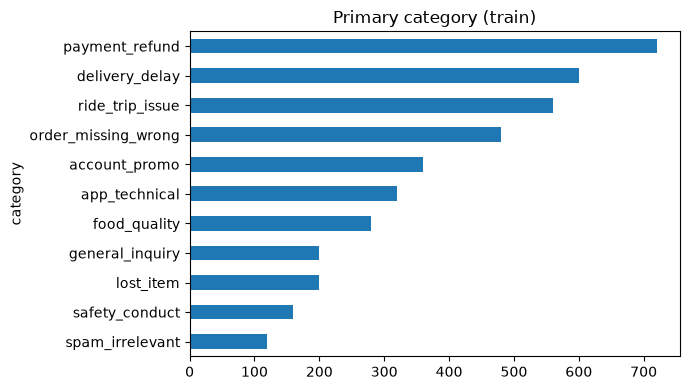

category
payment_refund         0.18
delivery_delay         0.15
ride_trip_issue        0.14
order_missing_wrong    0.12
account_promo          0.09
app_technical          0.08
food_quality           0.07
general_inquiry        0.05
lost_item              0.05
safety_conduct         0.04
spam_irrelevant        0.03
Name: proportion, dtype: float64

In [5]:
ax = train.category.value_counts().plot.barh(figsize=(7,4), title='Primary category (train)')
ax.invert_yaxis(); plt.tight_layout(); plt.show()
train.category.value_counts(normalize=True).round(3)

**Summary — Category distribution**
- The 11 categories are imbalanced. `payment_refund` is the largest class (720 tickets, 18%) and `spam_irrelevant` the smallest (120 tickets, 3%), a **6x** difference.
- The counts decrease gradually rather than having one dominant class, but small classes (`spam_irrelevant`, `safety_conduct`, `lost_item`, `general_inquiry`) have far fewer examples to learn from.
- `safety_conduct` is small (4%) but the most critical class, since mistakes there have real-world safety consequences.
- **Actions:** use **macro-F1** as the main metric (every class counts equally), use **class weights** during training, and inspect per-class recall, especially for `safety_conduct`.

## 3. Language × category

In [6]:
pd.crosstab(train.category, train.language, margins=True)

language,en,mixed,si,singlish,ta,tanglish,All
category,,,,,,,
account_promo,126,9,72,90,54,9,360
app_technical,112,8,64,80,48,8,320
delivery_delay,210,15,120,150,90,15,600
food_quality,98,7,56,70,42,7,280
general_inquiry,70,5,40,50,30,5,200
lost_item,70,5,40,50,30,5,200
order_missing_wrong,168,12,96,120,72,12,480
payment_refund,252,18,144,180,108,18,720
ride_trip_issue,196,14,112,140,84,14,560


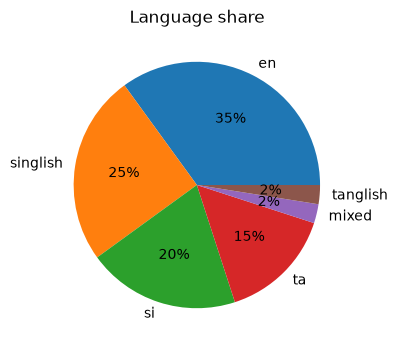

In [7]:
train.language.value_counts(normalize=True).round(3).plot.pie(autopct='%.0f%%', figsize=(4,4), ylabel='')
plt.title('Language share'); plt.show()

**Summary — Language share**
- Tickets come in six language forms: English 35%, Singlish 25%, Sinhala 20%, Tamil 15%, Tanglish 2.5% and mixed 2.5% (the pie chart rounds the last two to 2%).
- Sinhala-related tickets (Sinhala + Singlish) make up 45% of the data, more than English.
- Tanglish and mixed together are only 5% (200 tickets), so the model has very little data for them.
- The crosstab shows every category has the same language proportions, so language is not a shortcut for the category.
- **Action:** the model must handle native scripts and romanised text, and we will report scores **per language**.

**Summary — Language × Category**

| Finding | What we do about it |
|---|---|
| Language shares are identical across all categories (e.g. English is 35% of every category) | ✅ No language shortcut exists; the model must learn the actual content of the ticket |
| Tanglish and mixed have very little data (only 3–5 tickets per category for some classes, e.g. 4 Tanglish `safety_conduct` tickets) | ⚠️ Expect weaker performance on these languages; consider extra attention (e.g. augmentation, character n-grams, multilingual transformer) |
| The judges' evaluation data may have a different language mix | 📊 Report scores **per language**, not just the overall score, so a weak language is not hidden by a strong one |

## 4. Channel and subject

In [8]:
print(pd.crosstab(train.category, train.channel))
print('subject present by channel:'); print(train.subject.notna().groupby(train.channel).mean())

channel              call_transcript  chat  email
category                                         
account_promo                     93   152    115
app_technical                     69   156     95
delivery_delay                   156   273    171
food_quality                      71   123     86
general_inquiry                   44    91     65
lost_item                         48    88     64
order_missing_wrong              123   222    135
payment_refund                   189   321    210
ride_trip_issue                  150   244    166
safety_conduct                    26    82     52
spam_irrelevant                   31    48     41
subject present by channel:
channel
call_transcript    0.0
chat               0.0
email              1.0
Name: subject, dtype: float64


**Observations — Channel and subject**
- Channel shares: chat 45% (1,800), email 30% (1,200), call transcript 25% (1,000).
- Unlike language, channel proportions vary slightly by category. For example, `safety_conduct` arrives via chat more often (51% vs 45% overall) and via calls less often (16% vs 25%).
- These differences are small, so channel is a **weak signal**, not a shortcut. It is an allowed input field, so we include it in the model input.
- `subject` is present for 100% of emails and 0% of chat and call tickets. The email subject can contain the key issue, so the model input is `[channel] subject || text`.

## 5. Text length by language

In [ ]:
train['n_chars'] = train.text.str.len()
train.boxplot('n_chars', by='language', figsize=(7,4)); plt.suptitle(''); plt.show()
train.groupby('language').n_chars.describe().round(0)

## 6. Secondary category — which pairs occur?

In [ ]:
print('share with secondary:', train.secondary_category.notna().mean())
train[train.secondary_category.notna()].groupby(['category','secondary_category']).size()

## 7. Urgency

In [ ]:
print('urgent share:', train.is_urgent.mean())
pd.crosstab(train.category, train.is_urgent)

In [ ]:
pd.crosstab(train.language, train.is_urgent, normalize='index').round(3)

## 8. Adversarial patterns
Prompt-injection lines and quoted/resolved correspondence (see DATA_NOTES).

In [ ]:
inj = train.text.str.contains(r'ignore|previous instructions|mark this|classify', case=False)
print('injection-like tickets:', inj.sum())
print(train[inj].category.value_counts())
train[inj][['language','category','is_urgent','text']].sample(5, random_state=0)

In [ ]:
quoted = train.text.str.contains(r'resolved|wrote:|^>', case=False, regex=True)
print('quoted/resolved-like tickets:', quoted.sum())
train[quoted][['channel','subject','category','text']].sample(3, random_state=0)

## 9. Read a few tickets per category

In [ ]:
for cat in sorted(train.category.unique()):
    print('='*20, cat)
    for _, r in train[train.category == cat].sample(2, random_state=1).iterrows():
        print(f'[{r.language}/{r.channel}] urgent={r.is_urgent} sec={r.secondary_category}')
        print('  ', r.text[:250].replace('\n', ' / '))

## 10. Validation vs train distribution

In [ ]:
pd.DataFrame({'train': train.category.value_counts(normalize=True),
              'val': val.category.value_counts(normalize=True)}).round(3)

## Findings (fill in)
- 
- 
- 